# Practice Session 08: Communities

In this session we will use [NetworkX](https://networkx.github.io/) to compute communities on a graph. We will use a graph from the movies **Star Wars**.

The dataset is contained in this input file that you will find in our [data](https://github.com/chatox/networks-science-course/tree/master/practicum/data) directory:
* ``starwars.graphml``: co-occurence of characters in scenes in the Star Wars saga in [GraphML](http://graphml.graphdrawing.org/) format.


<font size="-1" color="gray">(Remove this cell when delivering.)</font>

In [1]:
# LEAVE AS-IS

import io
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import statistics

# 1. The graph

The following code just loads the graph into variable *g*. Leave as-is.

In [2]:
# LEAVE AS-IS

INPUT_GRAPH_FILENAME = "data/starwars/starwars.graphml"

# Read the graph in GraphML format
sw_in = nx.read_graphml(INPUT_GRAPH_FILENAME)

# Re-label the nodes so they use the 'name' as label
sw_relabeled = nx.relabel.relabel_nodes(sw_in, dict(sw_in.nodes(data='name')))

# Convert the graph to undirected
sw = sw_relabeled.to_undirected()

The following code, which you can leave as-is or modify for better visualization, displays a graph. It also accepts a ``partition`` argument, which we will use later on.

In [3]:
# LEAVE AS-IS (OR MODIFY VISUALLY)

def plot_graph(g, width=20, height=20, font_size=12, partition=None):

    # Create a plot of width x height
    plt.figure(figsize=(width, height))

    # By default the partition is going to be all nodes in the same partition
    if partition is None:
        partition = [ set(g.nodes()) ]

    # Number of partitions
    num_parts = len(partition)

    # Create a map from nodes to color using color values from 0.0 for the first partition
    # to 1-1/P for the last partition, assuming there are P partitions
    node_to_color = {}
    part_color = 0.0
    for part in partition:
        for node in part:
            node_to_color[node] = part_color
        part_color += 1.0/num_parts

    # Create a list of colors in the ordering of the nodes
    colors = [node_to_color[node] for node in g.nodes()]

    # Layout the nodes using a spring model
    nx.draw_spring(g, with_labels=True, node_size=1000, font_size=font_size,
                   cmap=plt.get_cmap('YlOrRd'), node_color=colors)

    # Display
    plt.show()

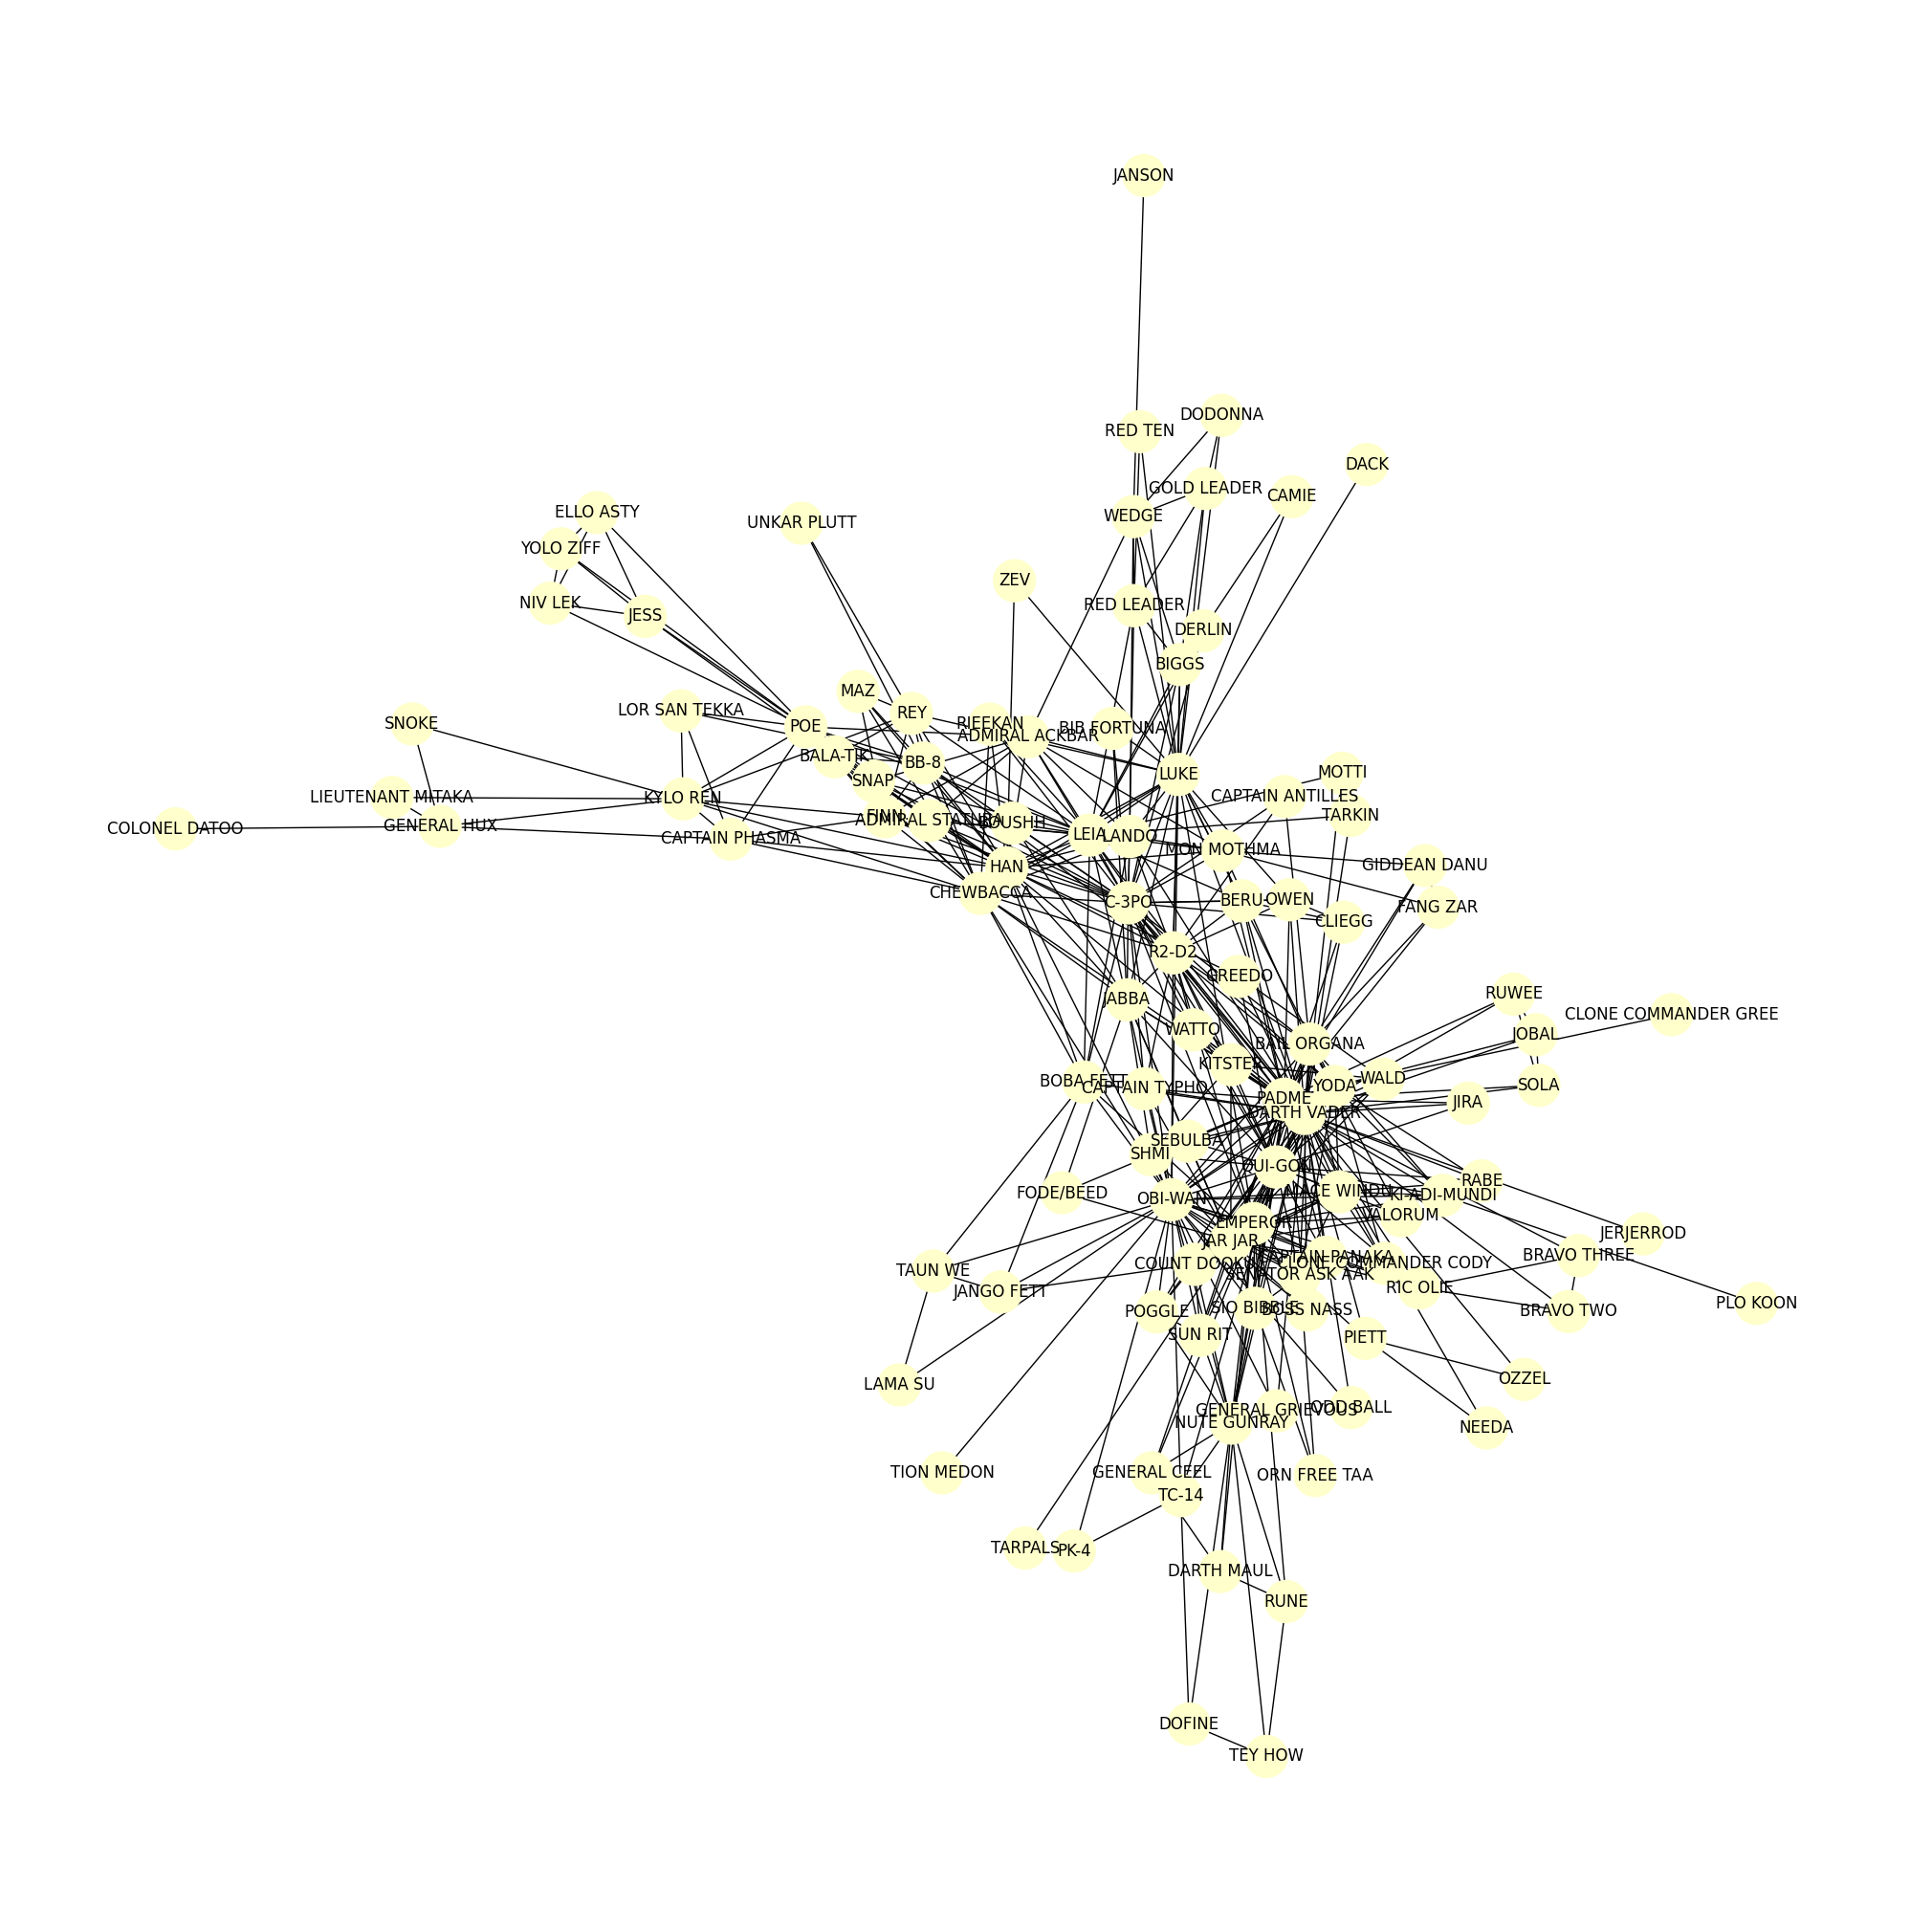

In [4]:
# LEAVE AS-IS

plot_graph(sw)

# 2. K-core decomposition

Now we will perform a k-core decomposition, using the following auxiliary functions, which you can leave as-is.

In [ ]:
# LEAVE AS-IS

def get_max_degree(g):
    degree_sequence = [x[1] for x in g.degree()]
    return(max(degree_sequence))


def nodes_with_degree_less_or_equal_than(g, degree):
    nodes = []
    for node in g.nodes():
        if g.degree(node) <= degree:
            nodes.append(node)
    return nodes

Create the function `kcore_decomposition(g)`.

This function must assign the corresponding k-core to each node. It must return a dictionary node_to_kcore_number where each key is the name of the node and their value is the corresponding kcore_number.  


Start with k = 1.
Find all nodes whose current degree is ≤ k. Here you can use the function `nodes_with_degree_less_or_equal_than(g, degree)`.  
While such nodes exist:   
- assign these nodes the k-core number k.  
- remove them from the graph.  
- recompute the degrees and find again all nodes with degree ≤ k.  

When no more nodes of degree ≤ k remain, increase k by 1.   
Repeat until k reaches the maximum degree or the graph is empty.  

<font size="+1" color="red">Replace this cell with your code for "kcore_decomposition". Please remember to include enough comments to explain what your code is doing.</font>

In [14]:
def kcore_decomposition(g):
    # This dictionary will store each node and the k-core value we assign to it
    node_to_kcore_number = {}

    # Work on a copy so we don't change the original graph
    H = g.copy()

    # Maximum degree in the graph (so we know how far k might go)
    max_degree = get_max_degree(H)

    # Start checking from k = 1
    k = 1

    # Keep going while the graph still has nodes
    # and while k is not higher than the max degree
    while H.number_of_nodes() > 0 and k <= max_degree:

        # Find all nodes with degree <= k in the current graph
        low_deg = nodes_with_degree_less_or_equal_than(H, k)

        # If none are found, move on to the next k value
        if not low_deg:
            k += 1
            continue

        # Assign k-core number k to all nodes that we are removing
        for n in low_deg:
            node_to_kcore_number[n] = k

        # Remove these nodes from the graph
        H.remove_nodes_from(low_deg)

    # Return the dictionary with all nodes and their k-core value
    return node_to_kcore_number


In [12]:
# LEAVE AS-IS

node_to_kcore = kcore_decomposition(sw)

for character in ["LEIA", "C-3PO", "REY", "TARKIN"]:
    print("K-core of {:s}: {:d}".format(character, node_to_kcore[character]))

K-core of LEIA: 7
K-core of C-3PO: 8
K-core of REY: 6
K-core of TARKIN: 3


Now, create a function to create a k-core subraph as a function of k. You can use [Graph.subgraph](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html). Execute the function to create and draw k-core subgraph `swcore`, containing only the nodes with k-core number greater or equal to **4**.

<font size="+1" color="red">Replace this cell with your code for create_kcores_subgraph(g,k), execute swcore=create_kcores_subgraph(sw,k) and plot the corresponding graph using the plot_graph function we provide.  
Please remember to include enough comments to explain what your code is doing.</font>

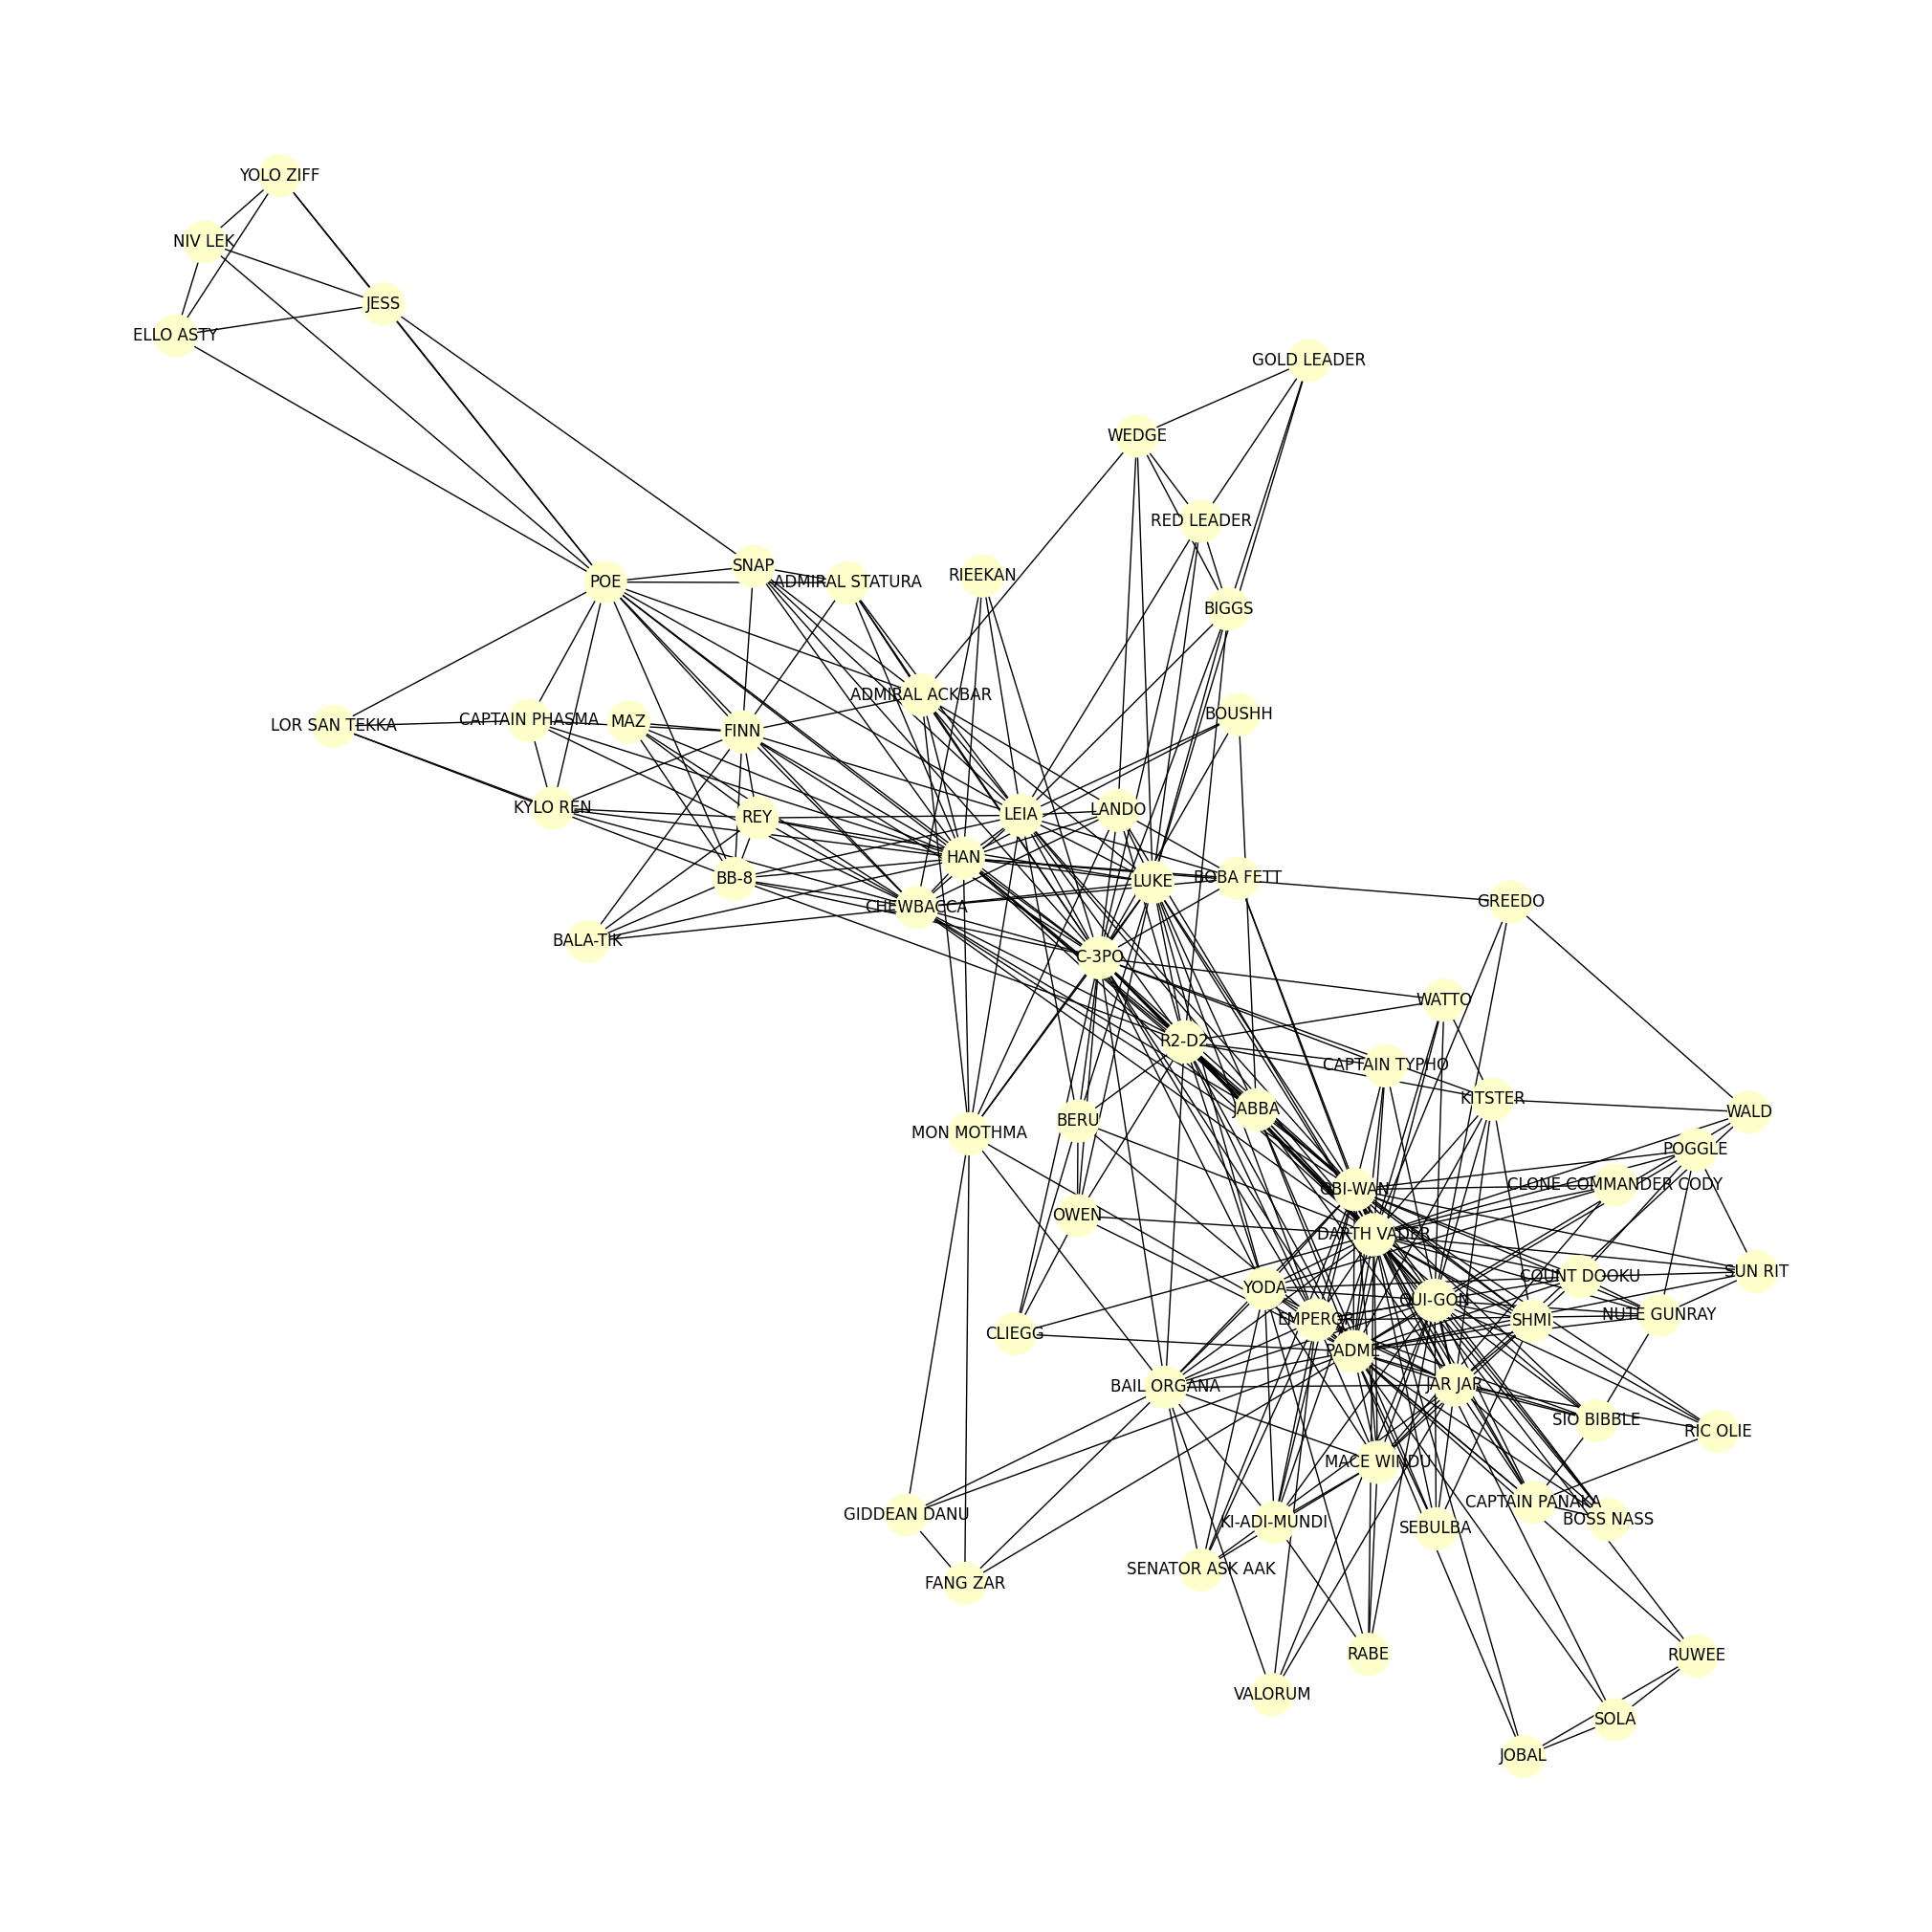

In [15]:
def create_kcores_subgraph(g, k):
    # First get the k-core number for every node
    kc = kcore_decomposition(g)

    # We will collect only the nodes that have k-core >= k
    good = []
    for n in kc:
        if kc[n] >= k:
            good.append(n)

    # Create and return the subgraph containing only those nodes
    return g.subgraph(good).copy()

# Create the subgraph for k = 4 and plot it
swcore = create_kcores_subgraph(sw, 4)
plot_graph(swcore)


# 3. Modularity of a partition

We will compute the modularity of a partitioning. First, let's draw a small toy graph.

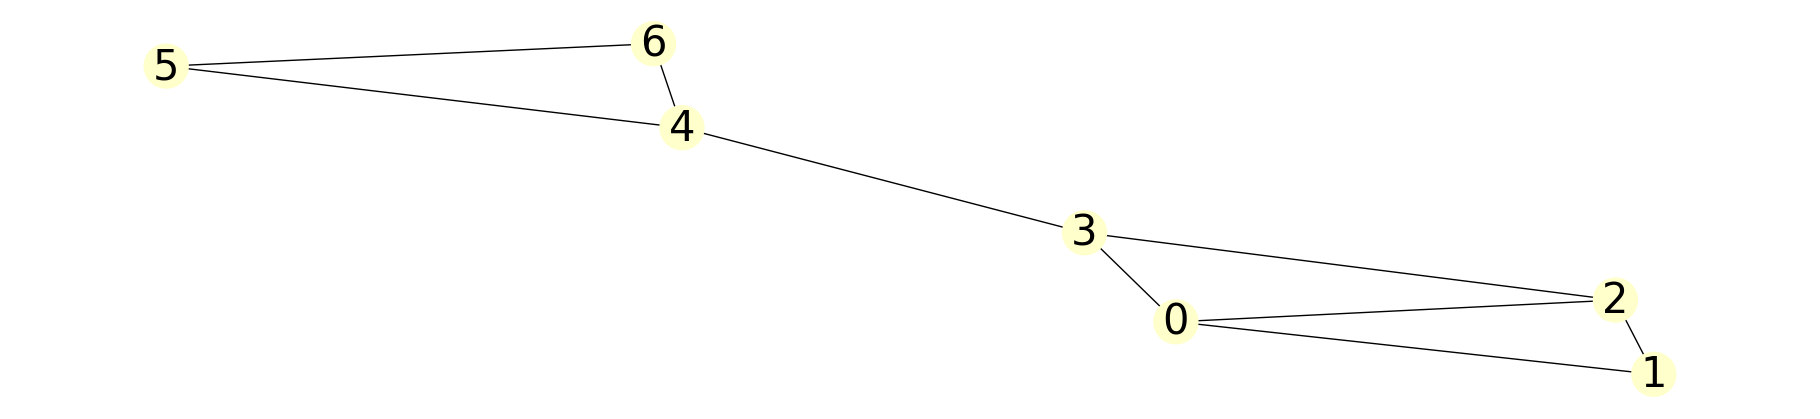

In [16]:
# Leave as-is

g = nx.Graph()

g.add_edge(0, 1)
g.add_edge(1, 2)
g.add_edge(2, 3)
g.add_edge(3, 0)
g.add_edge(0, 2)
g.add_edge(3, 4)
g.add_edge(4, 5)
g.add_edge(5, 6)
g.add_edge(6, 4)

# NOTE: for each run, the visualization will be different, but the graph should have the connections indicated above
plot_graph(g, height=4, width=18, font_size=30)

A partition of a graph is represented as a list of sets. Each set represents a part of the graph. For instance, the following are two partitions. The first one is arguably the most natural way of dividing this graph: nodes 0, 1, 2, 3 belong to one partition, and nodes 4, 5, and 6 to the other partition. The second one places the node 3 in the "wrong" partition.

NetworkX has a function to compute the modularity of a partition: [community.quality.modularity](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html). It applies the formula we discussed in class:

$$
Q = \frac{1}{L} \sum_{C} \left( L_C - \frac{k_C^2}{4L} \right)
$$

Where:

* Q is the modularity
* C is a community
* $L_{C}$ is the number of internal links in C (internal means connecting two nodes in C)
* $K_{C}$ is the summation of the degree of nodes in C
* L is the total number of links in the graph

Remember that in modularity, the greater it is the better partitioned it is.


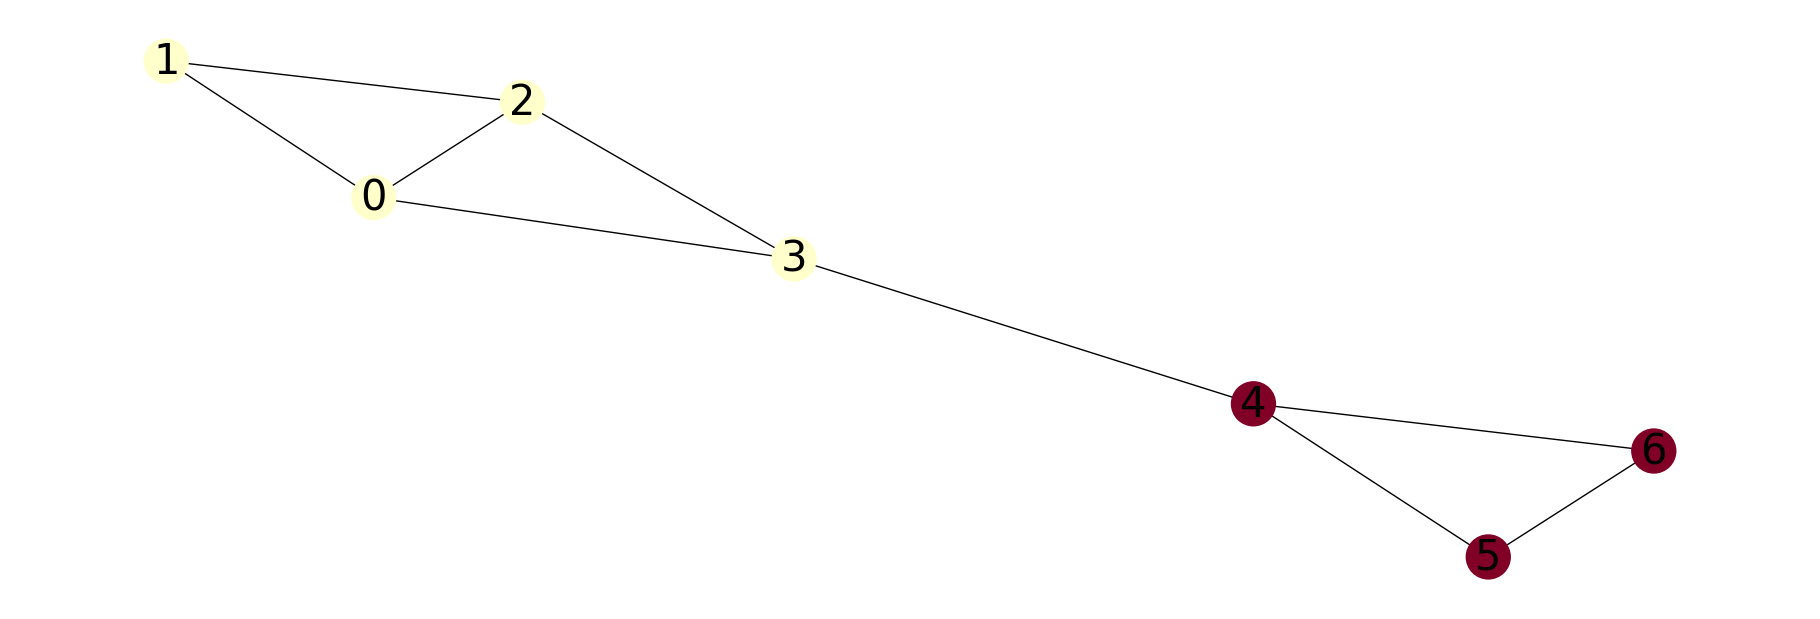

Modularity of partition 1 according to NetworkX: 0.3642


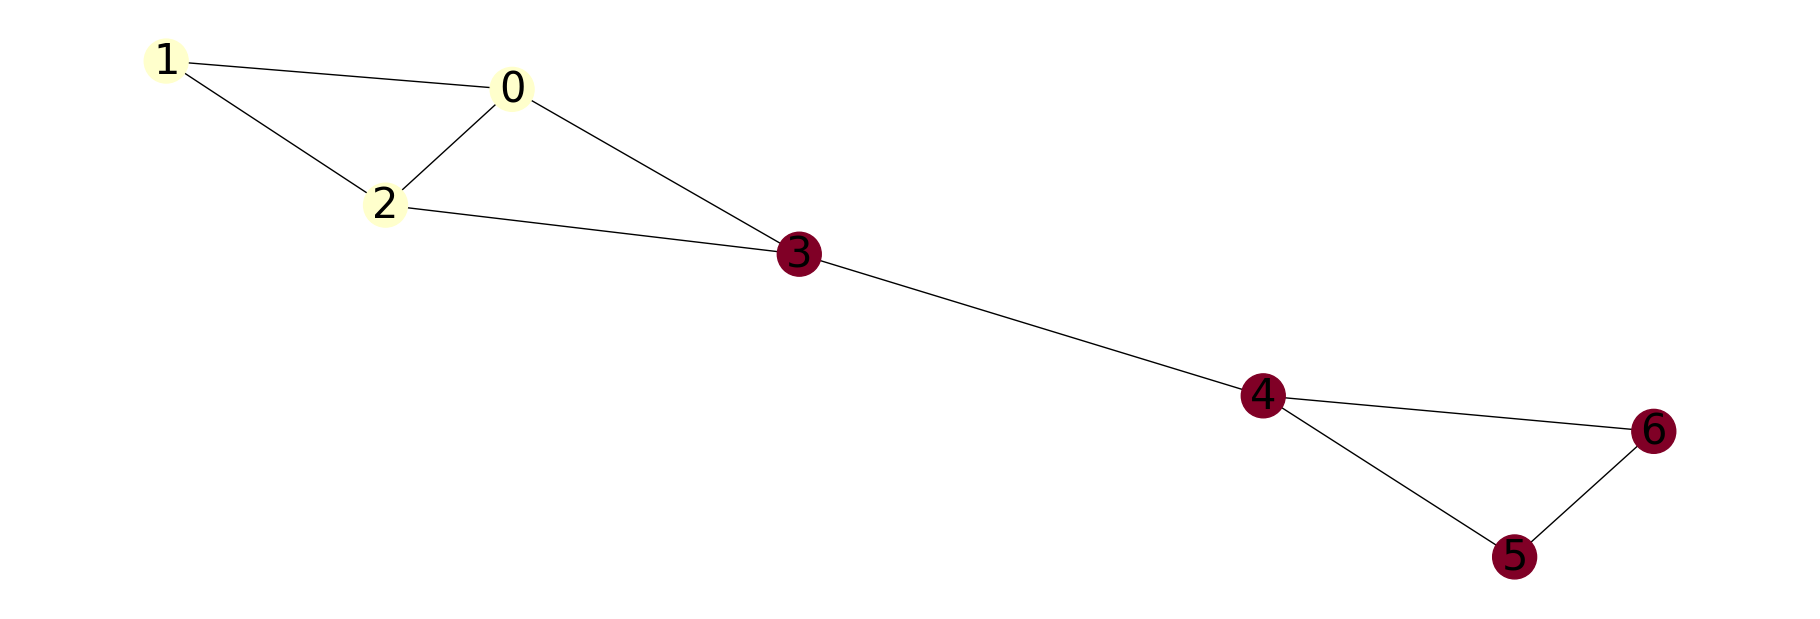

Modularity of partition 2 according to NetworkX: 0.2716


In [17]:
# LEAVE AS-IS

partition1 = [
    {0, 1, 2, 3},
    {4, 5, 6}
]
plot_graph(g, height=6, width=18, font_size=30, partition=partition1)
print("Modularity of partition 1 according to NetworkX: %.4f" % nx.community.quality.modularity(g, partition1))


partition2 = [
    {0, 1, 2},
    {3, 4, 5, 6}
]
plot_graph(g, height=6, width=18, font_size=30, partition=partition2)
print("Modularity of partition 2 according to NetworkX: %.4f" % nx.community.quality.modularity(g, partition2))

Create a function `modularity(g, partition)`. First, define two auxiliary functions:

* `Lc(g, C)`, returning the number of internal links within community C. An easy way of doing this is creating a [subgraph](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html) of g restricted to the nodes in C, and then counting the [number of edges](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.number_of_edges.html) in that subgraph.
* `kc(g, C)`, returning the sumation of the degree of nodes in C in the graph g (do not create a subgraph).

Then, write the function `modularity: def modularity(g, partition)` using these two auxiliary functions. Remember to use the formula defined in theory.

<font size="+1" color="red">Replace this cell with your code for `Lc(g, C)`, for `kc(g, C)` and for `modularity(g, partition)`.</font>

In [18]:
def Lc(g, C):
    # Create the subgraph that only contains the nodes in community C
    sub = g.subgraph(C)
    # Return how many edges are inside this community
    return sub.number_of_edges()


def kc(g, C):
    # Sum of the degrees of all nodes in community C (in the original graph g)
    total_degree = 0
    for node in C:
        total_degree += g.degree(node)
    return total_degree


def modularity(g, partition):
    # Total number of edges in the whole graph
    m = g.number_of_edges()

    # This will store the final modularity value
    Q = 0.0

    # Go through each community in the partition
    for C in partition:
        # Internal edges of this community
        L_c = Lc(g, C)
        # Sum of degrees of nodes in this community
        k_c = kc(g, C)

        # Add this community's contribution to modularity
        # Formula: (L_c / m) - (k_c / (2m))^2
        Q += (L_c / m) - (k_c / (2 * m)) ** 2

    return Q


Use the following to test your code.

In [19]:
# LEAVE AS-IS

print("Modularity of partition 1: mine={:.6f}, networkx={:.6f}".format(
    modularity(g, partition1), nx.community.quality.modularity(g, partition1)))

print("Modularity of partition 2: mine={:.6f}, networkx={:.6f}".format(
    modularity(g, partition2), nx.community.quality.modularity(g, partition2)))


Modularity of partition 1: mine=0.364198, networkx=0.364198
Modularity of partition 2: mine=0.271605, networkx=0.271605


# 4. Girvan-Newman algorithm

The Girvan-Newman algorithm generates a series of partitions of a graph. The first has simply the entire graph in one partition, and the last has one partition per node.

The way in which the algorithm operates is by iteratively removing the edge with the largest edge betweenness, and returning a new partition every time the number of connected components of the graph increases.

Now, write a function to find the edge with the largest betweenness in a graph.

First, use function [edge_betweenness_centrality](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.edge_betweenness_centrality.html) to obtain a dictionary in which keys are edges, and values are edge betweenness.

Then, iterate through those keys and find the one with the maximum edge betweenness. Return that key.

*Tip:* the dictionary returned by ``edge_betweenness_centrality`` sometimes has triples *(u,v,0)* as keys, instead of simple tuples *(u,v)*. In that case, remember to return simply *(u,v)*. You can check how many values a tuple *t* contains by using ``len(t)``.


<font size="+1" color="red">Replace this cell with your code for `largest_betweenness_edge`, using the edge_betweenness_centrality function in NetworkX</font>

In [20]:
def largest_betweenness_edge(g):
    # Get a dictionary with each edge and its betweenness value
    bet = nx.edge_betweenness_centrality(g)

    # We will keep track of the edge with the biggest betweenness
    best_edge = None
    best_value = -1

    # Go through all edges in the dictionary
    for t in bet:
        # Some keys may look like (u, v, 0). We only want (u, v).
        if len(t) > 2:
            edge = (t[0], t[1])
        else:
            edge = t

        value = bet[t]

        # Update if this edge has a larger betweenness than what we stored
        if value > best_value:
            best_value = value
            best_edge = edge

    # Return the edge with the highest betweenness
    return best_edge


We will use the following auxiliary function, that you can leave as-is. The reason we are introducing function `list_connected_components` is convenience, as the function [connected_components](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html) in NetworkX returns a [generator](https://wiki.python.org/moin/Generators) instead of a list.

In [21]:
# LEAVE AS-IS

def list_connected_components(g):
    return list(nx.connected_components(g))

def number_connected_components(g):
    return len(list_connected_components(g))


Now you will implement the `girvan_newman` algorithm:

The Newman–Girvan algorithm is a method to detect communities in a network. A community is a group of nodes that are more densely connected to each other than to the rest of the network. The algorithm identifies communities by removing edges that are “between” communities. The idea is that edges connecting different communities are more “important” in holding the network together, while edges inside a community are less critical.   

Your code has to:   
    - Create a partition sequence.  
    - Include the whole graph as the first partition.  
    - Iteratively, while the number of connected components is smaller thant the number of nodes:   
        - Compute edge betweenness.      
        - Remove the edge with the highest betweenness.   
        - Compute the number of connected components.  
        - I the number of connected components has increased add a the new list of connected components to the sequence.   

The output should be partition sequence, i.e., a list of partitions of the graph. In this particular case, the partition sequence looks like this:

```python
[[{0, 1, 2, 3, 4, 5, 6}],
 [{0, 1, 2, 3}, {4, 5, 6}],
 [{0, 2, 3}, {1}, {4, 5, 6}],
 ...
 [{0}, {1}, {2}, {3}, {4}, {5}, {6}]]
```

The way to interpret this is as follows:

* The first partition is simply all nodes in a single part
* The second partition happens after removing edge (3, 4), and divides the graph into two partitions
* The third partition happens after removing edges (0, 1) and (1, 2), ...
* ...
* The last partition happens after removing all edges, and each node is a singleton

<font size="+1" color="red">Replace this cell with your code for `girvan_newman`</font>

In [22]:
def girvan_newman(g):
    # Work on a copy of the graph so we do not change the original
    H = g.copy()

    # This list will store all partitions we generate
    partitions = []

    # First partition is the whole graph as one single community
    partitions.append(list_connected_components(H))

    # Continue until every node becomes its own component
    while number_connected_components(H) < H.number_of_nodes():

        # Find the edge with the largest betweenness in the current graph
        e = largest_betweenness_edge(H)

        # Remove this edge because it is “between” communities
        H.remove_edge(e[0], e[1])

        # Compute the new connected components and store them
        parts = list_connected_components(H)
        partitions.append(parts)

    # Return all partitions in order
    return partitions


In [23]:
# LEAVE AS-IS
def run_girvan_newman(g, graph_name="Graph"):

    partitions = girvan_newman(g)
    modularity_profile = []
    i = 1
    for partition in partitions:
        print("Number of partitions=" + str(i))
        print("Partition %s" % (partition,))
        m = modularity(g, partition)
        print("Modularity: %.4f" % m)
        modularity_profile.append(m)
        print()
        i += 1

    # Correct x-axis for plotting
    x = np.arange(1, len(modularity_profile) + 1)

    # Adjust point size inversely to number of points
    point_size = max(20, 200 / len(modularity_profile))

    plt.xlabel("Partition nº")
    plt.ylabel("Modularity")
    plt.title("Modularity profile")
    plt.scatter(x, modularity_profile, s=point_size, label=graph_name)
    plt.legend()


Number of partitions=1
Partition [{0, 1, 2, 3, 4, 5, 6}]
Modularity: 0.0000

Number of partitions=2
Partition [{0, 1, 2, 3}, {4, 5, 6}]
Modularity: 0.3642

Number of partitions=3
Partition [{0, 1, 2, 3}, {4, 5, 6}]
Modularity: 0.3642

Number of partitions=4
Partition [{0, 2, 3}, {1}, {4, 5, 6}]
Modularity: 0.2531

Number of partitions=5
Partition [{0, 2, 3}, {1}, {4, 5, 6}]
Modularity: 0.2531

Number of partitions=6
Partition [{0}, {1}, {2, 3}, {4, 5, 6}]
Modularity: 0.1420

Number of partitions=7
Partition [{0}, {1}, {2}, {3}, {4, 5, 6}]
Modularity: 0.0864

Number of partitions=8
Partition [{0}, {1}, {2}, {3}, {4, 5, 6}]
Modularity: 0.0864

Number of partitions=9
Partition [{0}, {1}, {2}, {3}, {4}, {5, 6}]
Modularity: -0.0617

Number of partitions=10
Partition [{0}, {1}, {2}, {3}, {4}, {5}, {6}]
Modularity: -0.1481



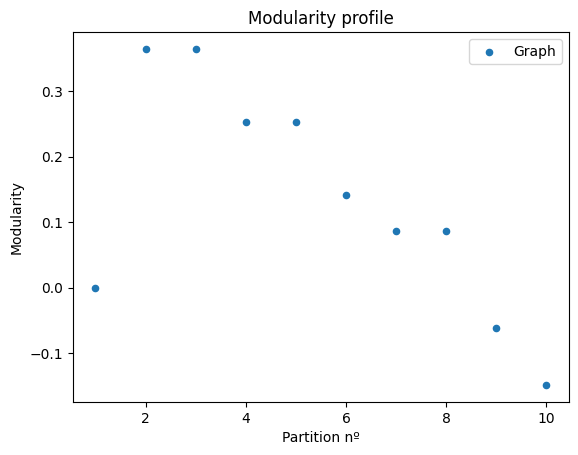

In [24]:
# LEAVE AS-IS

run_girvan_newman(g)

Number of partitions=1
Partition [{'QUI-GON', 'REY', 'CLONE COMMANDER GREE', 'SUN RIT', 'LEIA', 'JABBA', 'POE', 'DERLIN', 'DARTH VADER', 'MACE WINDU', 'JANGO FETT', 'CLIEGG', 'NIV LEK', 'LOR SAN TEKKA', 'KYLO REN', 'JIRA', 'DARTH MAUL', 'OBI-WAN', 'RED LEADER', 'LANDO', 'C-3PO', 'BOBA FETT', 'FODE/BEED', 'YOLO ZIFF', 'PIETT', 'TARKIN', 'SHMI', 'TC-14', 'ADMIRAL ACKBAR', 'JERJERROD', 'MOTTI', 'DACK', 'WATTO', 'COLONEL DATOO', 'YODA', 'RED TEN', 'KI-ADI-MUNDI', 'BIB FORTUNA', 'GENERAL GRIEVOUS', 'RUWEE', 'BOSS NASS', 'RUNE', 'SENATOR ASK AAK', 'KITSTER', 'BALA-TIK', 'LIEUTENANT MITAKA', 'TARPALS', 'NUTE GUNRAY', 'SNAP', 'DODONNA', 'HAN', 'JESS', 'CAMIE', 'JOBAL', 'MON MOTHMA', 'GREEDO', 'MAZ', 'RIEEKAN', 'CAPTAIN ANTILLES', 'OWEN', 'GENERAL HUX', 'SEBULBA', 'BRAVO TWO', 'GOLD LEADER', 'ADMIRAL STATURA', 'BRAVO THREE', 'NEEDA', 'LUKE', 'BOUSHH', 'PADME', 'ORN FREE TAA', 'COUNT DOOKU', 'ELLO ASTY', 'BIGGS', 'TION MEDON', 'POGGLE', 'TEY HOW', 'EMPEROR', 'VALORUM', 'CAPTAIN TYPHO', 'FANG ZAR

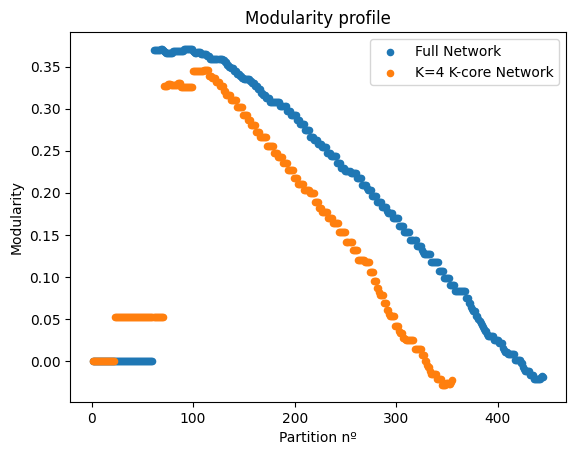

In [25]:
# LEAVE AS-IS

run_girvan_newman(sw,"Full Network")
run_girvan_newman(swcore, "K=4 K-core Network")

<font size="+1" color="red">Replace this cell with a brief answer to these questions:  
How many partitions result in highest modularity for each graph Full Network (sw) and k=4 (swcore)?.  
In general, how does modularity evolve with the number of partitions?
</font>

For the Full Network (sw), the highest modularity appears around the early part of the curve, roughly when there are about 80–100 partitions.
For the k = 4 k-core network (swcore), the peak happens much earlier, with around 10–20 partitions.

In general, modularity first increases as more meaningful communities are formed, reaches a maximum when the partitioning best matches the real community structure, and then drops as we keep removing edges and splitting the graph too much. When every node becomes isolated, modularity goes down again.

Create function `run_girvan_newman_modularity` that runs Girvan-Newman and returns the partition with the largest modularity.

<font size="+1" color="red">Replace this cell with your code for `run_girvan_newman_modularity`.</font>

In [26]:
def run_girvan_newman_modularity(g):
    # Run the Girvan–Newman algorithm to get all partitions
    partitions = girvan_newman(g)

    # We will track the best partition we find
    best_partition = None
    best_mod = -1

    # Go through every partition and compute its modularity
    for p in partitions:
        m = modularity(g, p)

        # Keep the one with the highest modularity
        if m > best_mod:
            best_mod = m
            best_partition = p

    # Return the best partition found
    return best_partition


The following cell, which you can leave as-is, runs this over the entire graph  and its corresponding k-core 4.

The best partition has modularity 0.3711 and 3 communities


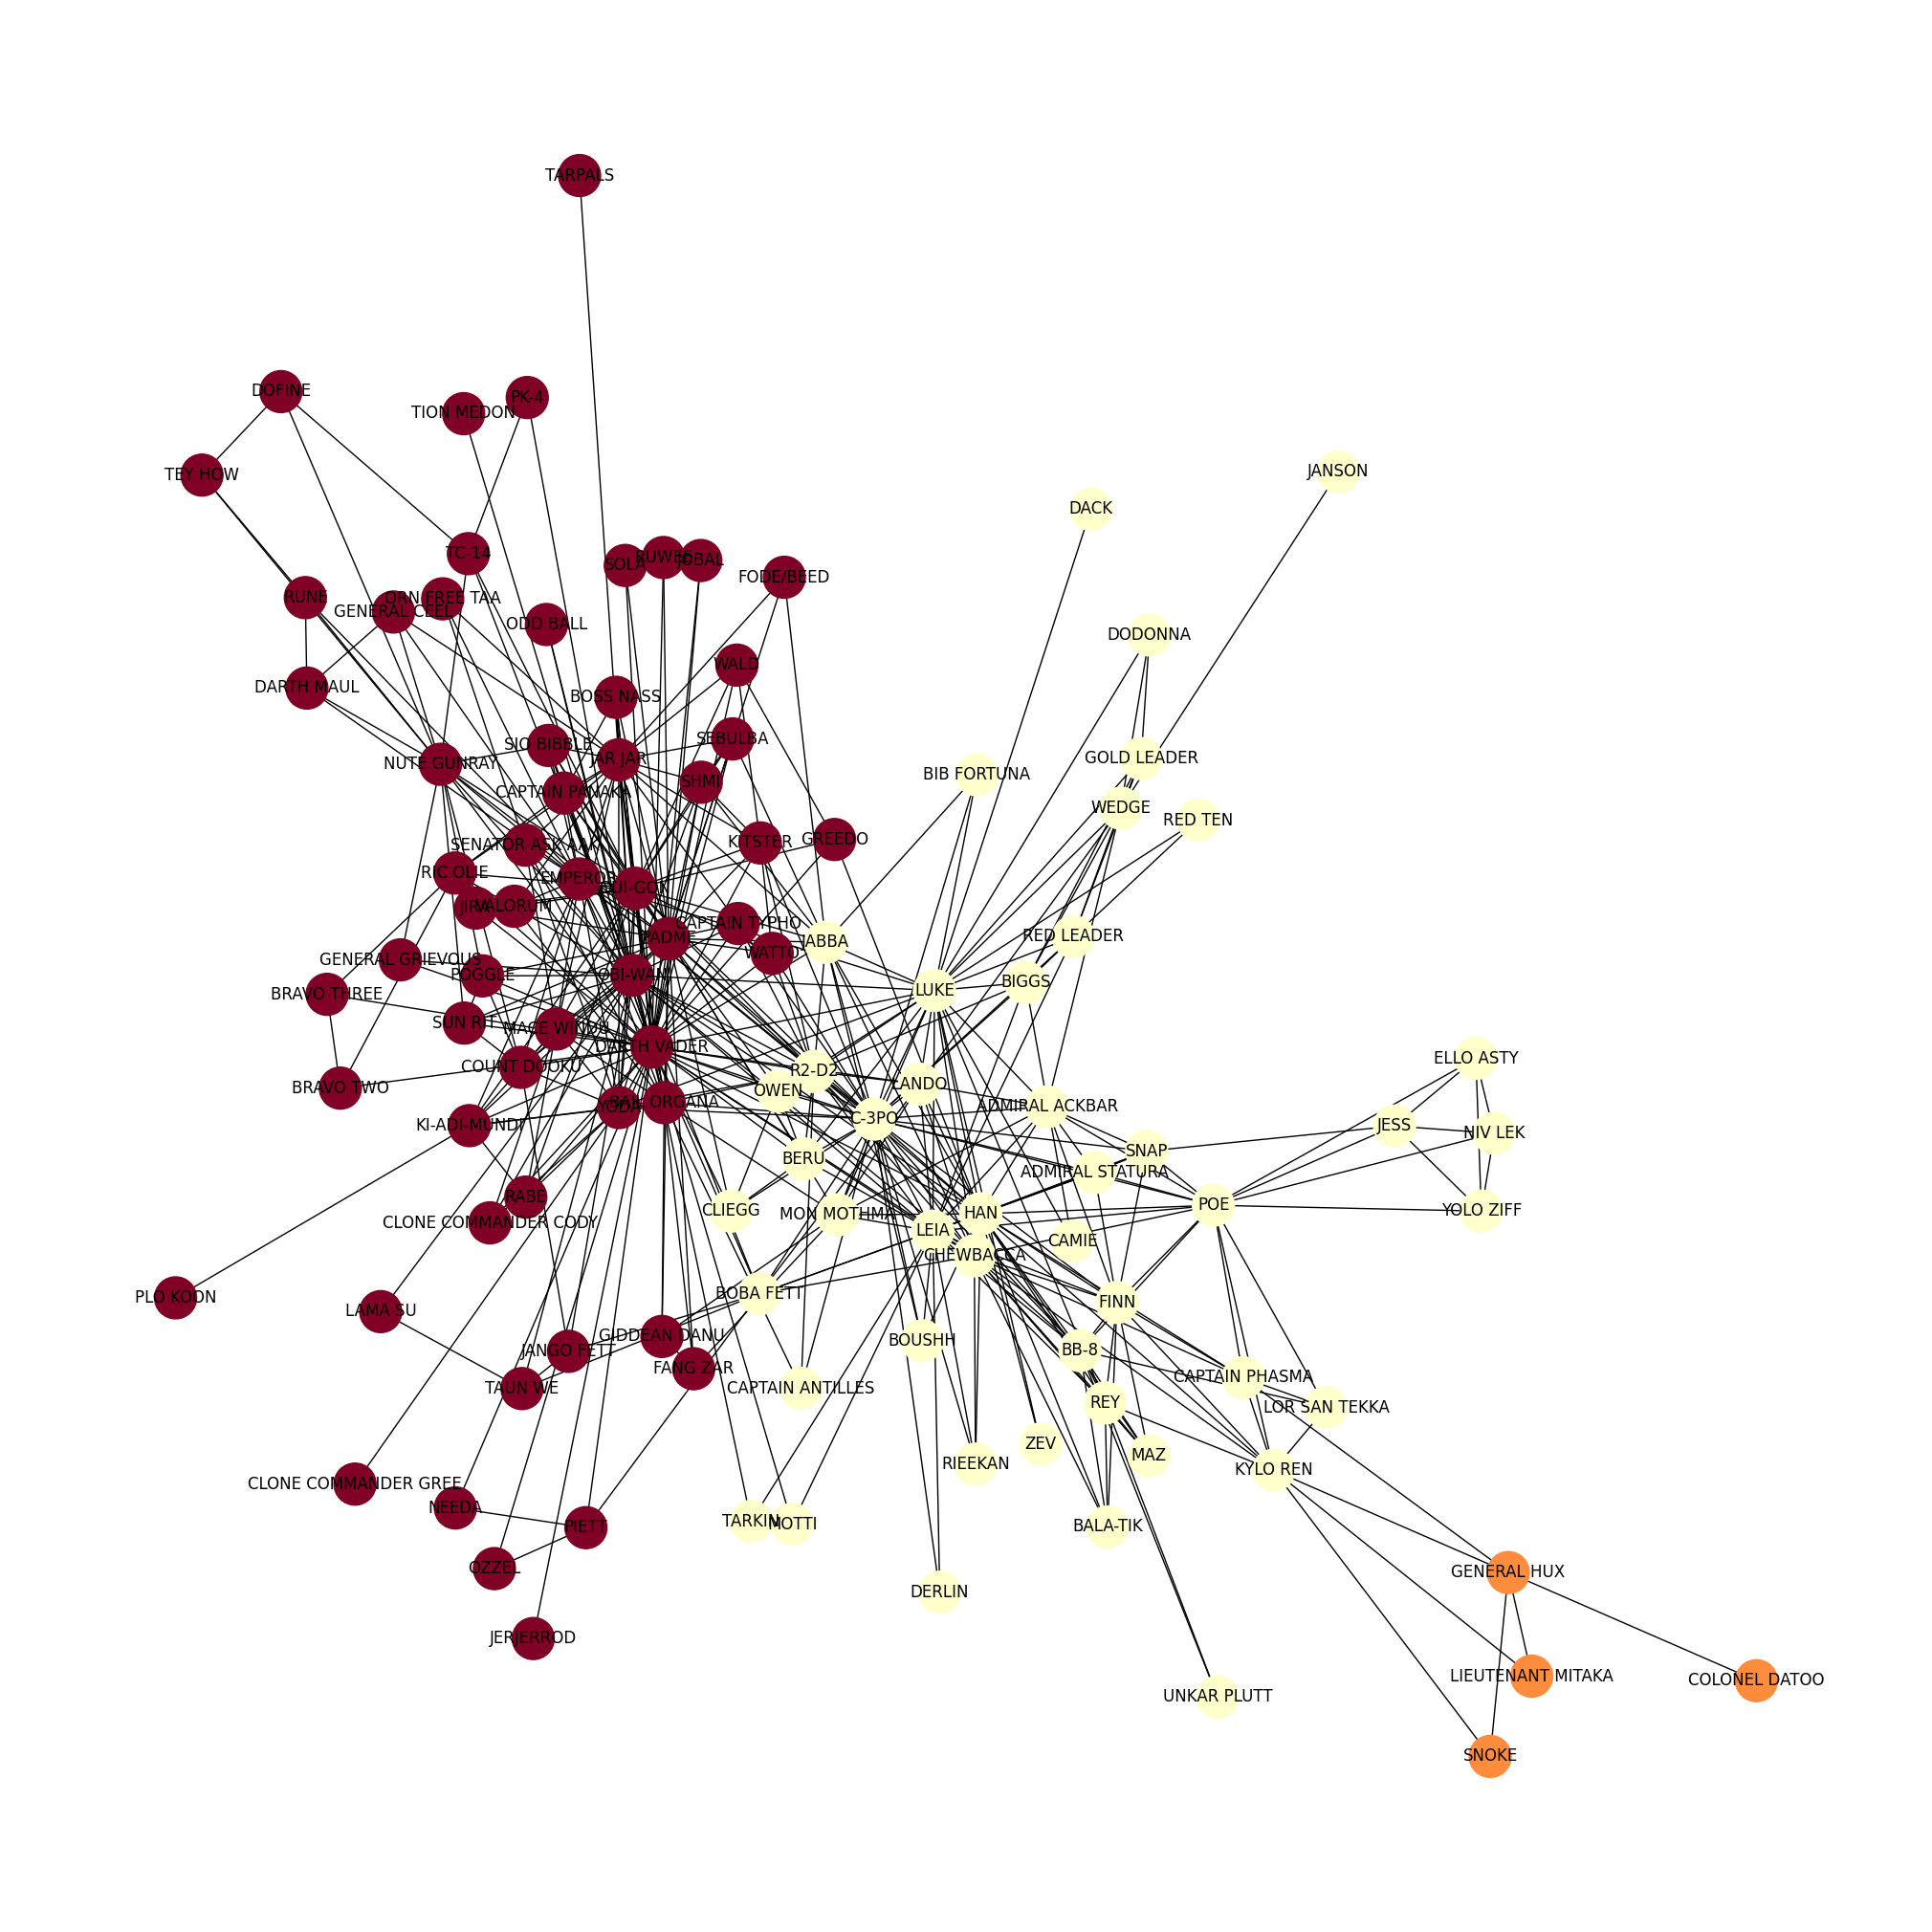

The best partition has modularity 0.3462 and 9 communities


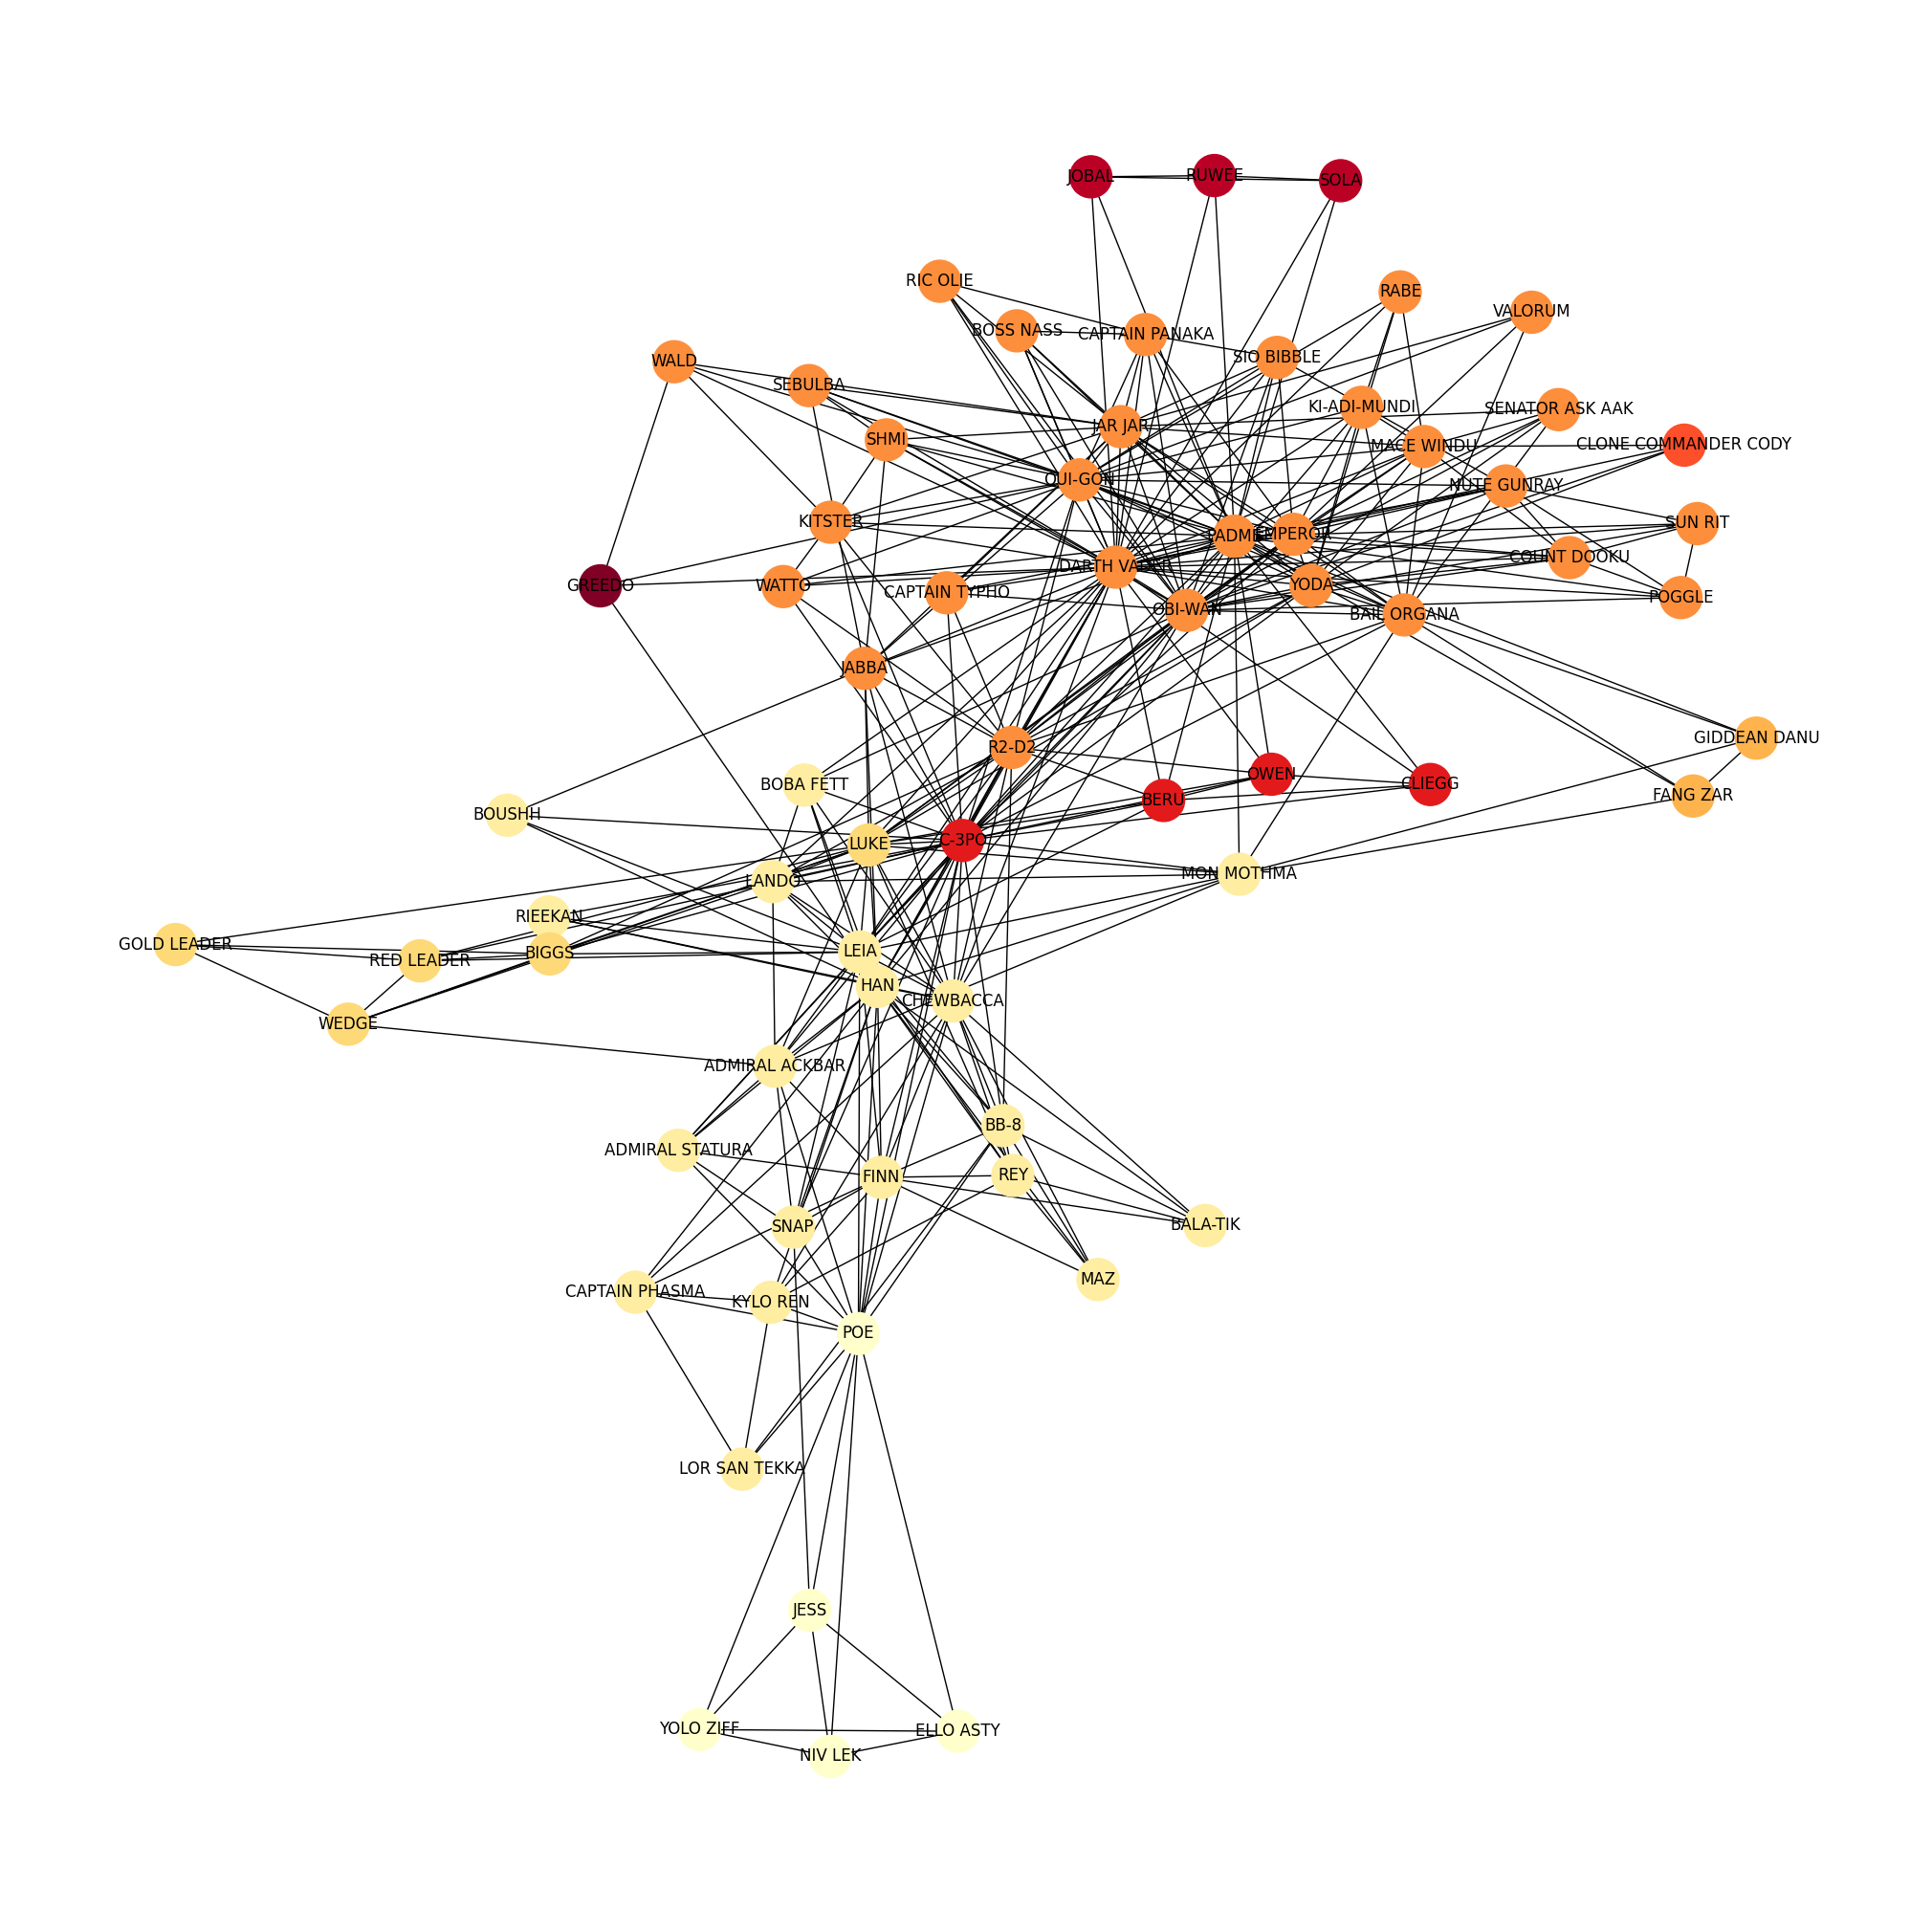

In [27]:
# LEAVE AS-IS

partition = run_girvan_newman_modularity(sw)
print("The best partition has modularity %.4f and %d communities" % (modularity(sw, partition), len(partition)))
plot_graph(sw, partition=partition)

partition = run_girvan_newman_modularity(swcore)
print("The best partition has modularity %.4f and %d communities" % (modularity(swcore, partition), len(partition)))
plot_graph(swcore, partition=partition)

<font size="+1" color="red">Replace this cell with a brief answer to the following questions regarding the COMPLETE GRAPH (sw)

How are the different communites connected between them? Why?  
You can look online to check if the characters in those communities are somehow related in the series. </font>

The communities are mostly connected through characters who appear in scenes with members of more than one group. These “bridge” characters usually sit at the intersection of different parts of the story, so they naturally create links between otherwise separate clusters.

In most cases, each community groups characters who share many scenes together, work toward similar goals, or belong to the same faction. The connections between different communities tend to be weaker and formed only when the plot brings those groups together. Because of that, the graph ends up with dense regions (tight communities) connected by a few key nodes that act as shared points between them.

# Deliver your code (individually)

A .zip file containing:

* This notebook.
* dataset following original structure "data/starwars/starwars.graphml"

<font size="+2" color="#003300">I hereby declare that, except for the code provided by the course instructors, all of my code, report, and figures were produced by myself.</font>